In [1]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder")
import utils as ut
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import json

In [2]:
#################
### Load Data ###
#################
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)
  
# Save to a new file for logging
#with open(f"used_settings.json", "w") as f:
#    json.dump(settings, f, indent=4)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
print("Dataset:", settings['dataset_trefht'])
ds

Dataset: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/europe_10percent_masked_stacked_TREFHT_JJA.nc


<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...

In [3]:
##########################
### create dummy array ###
##########################

da = xr.DataArray(
    np.zeros((32, 32)),
    dims=("lat", "lon"),
    coords={"lat": ds.lat, "lon": ds.lon},
    name="zeros",
)
da

<xarray.DataArray 'zeros' (lat: 32, lon: 32)> Size: 8kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5

In [4]:
# temperature domain 
lw=0.5

# Germany
lat_south_ger = 48.534031
lat_north_ger = 53.246073
lon_west_ger = 6.25
lon_east_ger = 15

boundary_south_lon_ger = np.linspace(lon_west_ger, lon_east_ger, 100)
boundary_south_lat_ger =np.full(100, lat_south_ger)

boundary_east_lat_ger = np.linspace(lat_south_ger, lat_north_ger, 100)
boundary_east_lon_ger = np.full(100, lon_east_ger)

boundary_north_lon_ger = np.linspace(lon_west_ger, lon_east_ger, 100)
boundary_north_lat_ger = np.full(100, lat_north_ger)

boundary_west_lat_ger = np.linspace(lat_south_ger, lat_north_ger, 100)
boundary_west_lon_ger = np.full(100, lon_west_ger)

# France
lat_south_fr = 45
lat_north_fr = 50
lon_west_fr = 0
lon_east_fr = 5

boundary_south_lon_fr = np.linspace(lon_west_fr, lon_east_fr, 100)
boundary_south_lat_fr =np.full(100, lat_south_fr)

boundary_east_lat_fr = np.linspace(lat_south_fr, lat_north_fr, 100)
boundary_east_lon_fr = np.full(100, lon_east_fr)

boundary_north_lon_fr = np.linspace(lon_west_fr, lon_east_fr, 100)
boundary_north_lat_fr = np.full(100, lat_north_fr)

boundary_west_lat_fr = np.linspace(lat_south_fr, lat_north_fr, 100)
boundary_west_lon_fr = np.full(100, lon_west_fr)

# Spain
lat_south_sp = 38
lat_north_sp = 42
lon_west_sp = -8
lon_east_sp = 0

boundary_south_lon_sp = np.linspace(lon_west_sp, lon_east_sp, 100)
boundary_south_lat_sp =np.full(100, lat_south_sp)

boundary_east_lat_sp = np.linspace(lat_south_sp, lat_north_sp, 100)
boundary_east_lon_sp = np.full(100, lon_east_sp)

boundary_north_lon_sp = np.linspace(lon_west_sp, lon_east_sp, 100)
boundary_north_lat_sp = np.full(100, lat_north_sp)

boundary_west_lat_sp = np.linspace(lat_south_sp, lat_north_sp, 100)
boundary_west_lon_sp = np.full(100, lon_west_sp)

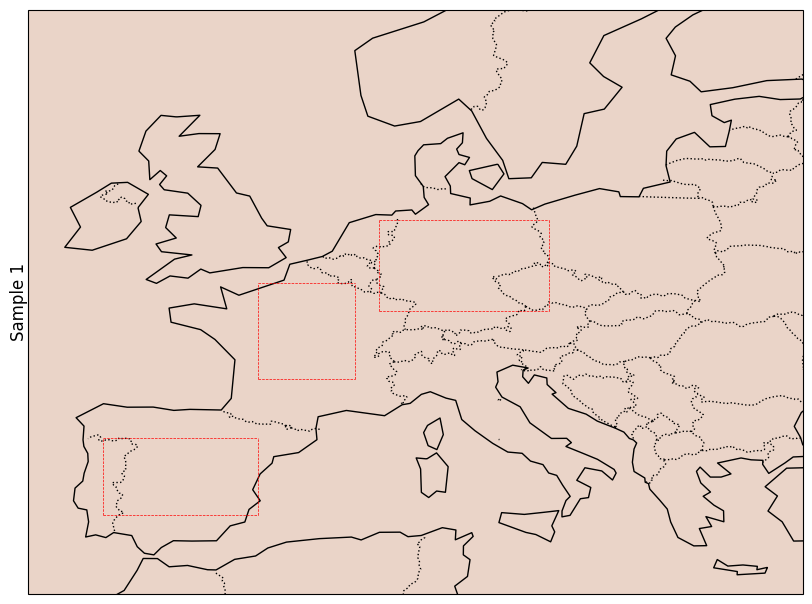

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
plot = ut.plot_temperature_panel(ax, da, vmax_shared=5, sample_nr = "Sample 1")

# Germany temp box
ax.plot(boundary_west_lon_ger,boundary_west_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_south_lon_ger,boundary_south_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_east_lon_ger,boundary_east_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_north_lon_ger,boundary_north_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed', label="T")

# France temp box
ax.plot(boundary_west_lon_fr,boundary_west_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_south_lon_fr,boundary_south_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_east_lon_fr,boundary_east_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_north_lon_fr,boundary_north_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed', label="T")

# Spain temp box
ax.plot(boundary_west_lon_sp,boundary_west_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_south_lon_sp,boundary_south_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_east_lon_sp,boundary_east_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_north_lon_sp,boundary_north_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed', label="T")

In [15]:
plot